# Fault Detection on Distributed Transmission Lines (TL-1 – TL-4)

### Benchmarking S4D/MS4, Mamba-2, KAN, ANN, PSO, LSTM and LRCN

Binary fault detection (**No Fault** vs. **Fault**) on three-phase voltage and
current waveforms from four transmission-line configurations, comparing seven
model families under a single training protocol.

| # | Model | Family | Input |
|---|-------|--------|-------|
| 1 | **MS4N / MS4 (S4D)** | Diagonal structured SSM | raw window |
| 2 | **Mamba-2** | Input-dependent SSM (SSD) | raw window |
| 3 | **KAN** | Kolmogorov–Arnold network | descriptors |
| 4 | **ANN** | Plain feed-forward MLP | descriptors |
| 5 | **PSO-ELM** | Metaheuristic + closed-form learner | descriptors |
| 6 | **LSTM** | Recurrent | raw window |
| 7 | **LRCN** | Convolutional–recurrent hybrid | raw window |

The MS4/MS4N design follows Saadatmand et al., *A Simple State Space Model Excels
at Multivariate Time Series Classification* (arXiv:2605.27406): S4D plus a
learnable input projection, gated channel mixing, and a single LayerNorm.

---

## ⚠️ Read this before reporting any numbers

Four properties of these CSVs will silently invalidate results if not handled.
Everything below is addressed in the pipeline, but each needs a sentence in the paper.

**1. TL-1, TL-3 and TL-4 are tiled, not independent.** Each 2000-row block is a
~500-sample segment repeated four times *exactly*. TL-1 holds 5,510 unique rows
out of 21,999. A random row- or window-level split puts byte-identical samples in
both train and test, which inflates accuracy to ~100%. The pipeline detects the
repetition period and keeps one copy.

**2. `TL_3_fault_classification.csv` duplicates `TL_4_fault_classification.csv`.**
They differ by at most 0.185 across all 132k values — about 7×10⁻⁶ relative on a
±27.7 kV signal, i.e. float rounding. The documentation says TL-3 is load-end and
TL-4 source-end faults, but these are one simulation saved twice. TL-3 also carries
21 corrupted labels (isolated single-row flips, plus two rows labelled `0`, which
is not in the codebook). The *detection* files for TL-3 and TL-4 genuinely differ
(identical pre-fault steady state, fault region diverging by 34 kV), so the real
TL-3 data survives only there — which is what this pipeline loads.

**3. Fault regions are concatenated simulations.** The fault block is ten separate
runs (one per fault type) spliced end to end. A window spanning a boundary is two
unrelated simulations glued together. Segments here come from the fault-type
labels, so no window crosses a join.

**4. Splits must be by time position, not at random.** Overlapping windows share
samples, so a shuffled split leaks. Each segment is cut into train/val/test by
position with a guard band of `L` samples between splits.

**A note on difficulty.** On clean data every model here scores ≈1.000 — a
comparison figure of seven identical bars demonstrates only that the task is
trivial. Additive noise at a stated SNR is used to restore discrimination; this
is also the realistic case, since instrument transformers and A/D front-ends are
never noiseless. The SNR sweep in Section 8 is the honest way to present this.

## 1. Setup

In [4]:
import os, sys, time, math, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as Fn
import matplotlib.pyplot as plt

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve,
                             balanced_accuracy_score, matthews_corrcoef,
                             classification_report)

torch.set_num_threads(max(1, os.cpu_count() // 2))
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42

def set_seed(s=SEED):
    np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

print('torch', torch.__version__, '| device', DEVICE)

torch 2.13.0+cpu | device cpu


### Configuration

`SNR_DB = None` gives the clean (saturated) task. Set it to a number to add
white Gaussian noise at that signal-to-noise ratio.

In [5]:
DATA_DIR = r'C:\Users\wasif\Downloads\30615710' + os.sep      # <-- point at your CSV folder
OUT_DIR  = './outputs'
os.makedirs(OUT_DIR, exist_ok=True)

WINDOW_LEN = 32       # samples per window (~1/5 cycle at TL-1/3/4's ~8.3 kHz)
STRIDE     = 2        # window hop; 1 = densest
SNR_DB     = 0.0      # None = clean; 0 dB = noise power equals signal power
EPOCHS     = 30
BATCH_SIZE = 128
LR         = 1e-3
PATIENCE   = 8
SPLITS     = (0.60, 0.15, 0.25)

CLASS_NAMES = ['No Fault', 'Fault']
FEATS = ['voltage_phase_a', 'voltage_phase_b', 'voltage_phase_c',
         'current_phase_a', 'current_phase_b', 'current_phase_c']
N_FEATS = len(FEATS)

## 2. Data pipeline

### 2.1 Source files

TL-1/2/4 come from the classification CSVs — they carry per-fault-type block
boundaries needed for correct segmentation, and the detection CSVs are a strict
subset of them (verified: every detection row appears in the corresponding
classification file), so nothing is lost. TL-3 comes from its detection CSV for
the reason given above.

In [6]:
CASE_SOURCE = {
    'TL-1': ('TL_1_fault_classification.csv', 'cls'),
    'TL-2': ('TL_2_fault_classification.csv', 'cls'),
    'TL-3': ('TL_3_fault_detection.csv',      'det'),   # genuine load-end data
    'TL-4': ('TL_4_fault_classification.csv', 'cls'),
}
CASES = list(CASE_SOURCE)

def load_case(case, root=DATA_DIR):
    """Returns X, binary label (0 = No Fault, 1 = Fault), and a grouping key
    identifying physically separate simulation runs."""
    fname, kind = CASE_SOURCE[case]
    df = pd.read_csv(root + fname, encoding='utf-8-sig')
    X = df[FEATS].to_numpy(dtype=np.float64)
    t = df['types'].to_numpy(dtype=np.int64)
    y = (t != 1).astype(np.int64) if kind == 'cls' else (t == 2).astype(np.int64)
    return X, y, t                      # `t` groups by fault type

### 2.2 Diagnostics — verifying the four hazards

In [7]:
print(f'{"case":6} {"rows":>7} {"unique":>8} {"tiling":>8}  label counts')
for c in CASES:
    X, y, t = load_case(c)
    uniq = len(np.unique(X, axis=0))
    print(f'{c:6} {len(X):7,} {uniq:8,} {len(X)/uniq:7.2f}x  '
          f'NoFault={int((y==0).sum()):,} Fault={int((y==1).sum()):,}')

X3, _, _ = load_case('TL-3'); X4, _, _ = load_case('TL-4')
c3 = pd.read_csv(DATA_DIR + 'TL_3_fault_classification.csv', encoding='utf-8-sig')
c4 = pd.read_csv(DATA_DIR + 'TL_4_fault_classification.csv', encoding='utf-8-sig')
d = np.abs(c3[FEATS].to_numpy() - c4[FEATS].to_numpy()).max()
print(f'\nTL-3 vs TL-4 classification files: max |difference| = {d:.4f} '
      f'({d/np.abs(c4[FEATS].to_numpy()).max()*100:.1e}% of full scale)')
print(f'   -> duplicate files; label disagreements: {int((c3.types!=c4.types).sum())}')

case      rows   unique   tiling  label counts
TL-1    21,999    5,510    3.99x  NoFault=1,999 Fault=20,000
TL-2    21,999   21,999    1.00x  NoFault=2,000 Fault=19,999
TL-3    11,999    5,505    2.18x  NoFault=2,000 Fault=9,999
TL-4    21,999    6,252    3.52x  NoFault=1,999 Fault=20,000

TL-3 vs TL-4 classification files: max |difference| = 0.1853 (6.7e-04% of full scale)
   -> duplicate files; label disagreements: 21


### 2.3 Segmentation, tiling collapse, and leakage-safe windowing

In [8]:
def find_segments(X, group, min_len=64, jump_factor=10.0):
    """Contiguous runs: split by fault-type change, then by signal discontinuity.
    Windowing across a boundary would splice two unrelated simulations."""
    bounds = [0] + [i for i in range(1, len(group)) if group[i] != group[i-1]] + [len(group)]
    segments = []
    for s, e in zip(bounds[:-1], bounds[1:]):
        d = np.abs(np.diff(X[s:e], axis=0)).max(axis=1)
        thr = jump_factor * np.median(d) + 1e-12
        cuts = [s] + [s + 1 + i for i in np.flatnonzero(d > thr)] + [e]
        for a, b in zip(cuts[:-1], cuts[1:]):
            if b - a >= min_len:
                segments.append((a, b))
    return segments


def tiling_period(a, min_p=20, tol=1e-6):
    """Smallest p with a[p:] == a[:-p]. TL-1/3/4 repeat a ~500-sample segment
    four times; without collapsing this, identical rows leak across splits."""
    n = len(a)
    for p in range(min_p, n // 2 + 1):
        if np.abs(a[p:] - a[:-p]).max() < tol:
            return p
    return n


def add_awgn(W, snr_db, rng):
    """Per-window, per-channel white Gaussian noise at a given SNR."""
    if snr_db is None:
        return W
    p_sig = (W.astype(np.float64) ** 2).mean(axis=1, keepdims=True)
    sigma = np.sqrt(p_sig / (10 ** (snr_db / 10.0)))
    return (W + sigma * rng.standard_normal(W.shape)).astype(np.float32)


def build_windows(case, L=WINDOW_LEN, stride=STRIDE, splits=SPLITS, root=DATA_DIR,
                  verbose=True):
    """Window each de-tiled segment, splitting BY TIME POSITION with a guard band
    of L samples so no test window shares a single sample with a train window."""
    X, y, group = load_case(case, root)
    segs = find_segments(X, group, min_len=L + 8)
    out = {k: {'X': [], 'y': []} for k in ('train', 'val', 'test')}
    n_unique = 0
    for a, b in segs:
        lab = int(np.round(y[a:b].mean()))
        seg = X[a:b]
        p = tiling_period(seg)
        seg = seg[:p]; n_unique += p
        starts = np.arange(0, p - L + 1, stride)
        if len(starts) < 12:
            continue
        n = len(starts)
        i1 = int(splits[0] * n); i2 = i1 + int(splits[1] * n)
        guard = max(1, L // stride)
        parts = {'train': starts[:max(i1 - guard, 1)],
                 'val':   starts[i1:max(i2 - guard, i1 + 1)],
                 'test':  starts[i2:]}
        for k, st in parts.items():
            for s0 in st:
                out[k]['X'].append(seg[s0:s0 + L]); out[k]['y'].append(lab)
    res = {k: (np.asarray(v['X'], dtype=np.float32), np.asarray(v['y'], dtype=np.int64))
           for k, v in out.items()}
    if verbose:
        print(f'  {case}: {len(segs):2d} segments, {n_unique:6,} unique samples -> '
              f"train {res['train'][0].shape[0]:6,}  val {res['val'][0].shape[0]:5,}  "
              f"test {res['test'][0].shape[0]:6,}")
    return res


def build_pooled(cases=CASES, L=WINDOW_LEN, stride=STRIDE, snr_db=SNR_DB,
                 seed=SEED, verbose=True):
    """Per-case z-scoring fitted on that case's TRAIN split only, then pooled.
    Per-case scaling is essential: TL-2's magnitudes differ from TL-1/3/4 by ~50x."""
    acc = {k: {'X': [], 'y': [], 'case': []} for k in ('train', 'val', 'test')}
    rng = np.random.default_rng(seed)
    for c in cases:
        d = build_windows(c, L=L, stride=stride, verbose=verbose)
        d = {k: (add_awgn(v[0], snr_db, rng), v[1]) for k, v in d.items()}
        flat = d['train'][0].reshape(-1, N_FEATS)
        mu, sd = flat.mean(0), flat.std(0) + 1e-8
        for k, v in d.items():
            acc[k]['X'].append(((v[0] - mu) / sd).astype(np.float32))
            acc[k]['y'].append(v[1])
            acc[k]['case'].append(np.full(len(v[1]), c, dtype=object))
    return {k: (np.concatenate(v['X']), np.concatenate(v['y']), np.concatenate(v['case']))
            for k, v in acc.items()}

In [9]:
pooled = build_pooled()
X_train, y_train, _      = pooled['train']
X_val,   y_val,   _      = pooled['val']
X_test,  y_test,  case_test = pooled['test']

print(f'\ntrain {X_train.shape}   val {X_val.shape}   test {X_test.shape}')
print(f'fault fraction — train {y_train.mean():.3f}  val {y_val.mean():.3f}  '
      f'test {y_test.mean():.3f}')
print(f'majority-class baseline accuracy on test: {max(y_test.mean(), 1-y_test.mean()):.4f}')

  TL-1: 11 segments,  7,000 unique samples -> train  1,825  val   321  test    837
  TL-2: 11 segments, 21,999 unique samples -> train  6,324  val 1,441  test  2,717
  TL-3: 11 segments,  5,998 unique samples -> train  1,524  val   246  test    712
  TL-4: 11 segments,  7,000 unique samples -> train  1,825  val   321  test    837

train (11498, 32, 6)   val (2329, 32, 6)   test (5103, 32, 6)
fault fraction — train 0.917  val 0.919  test 0.917
majority-class baseline accuracy on test: 0.9169


### 2.4 Waveform inspection

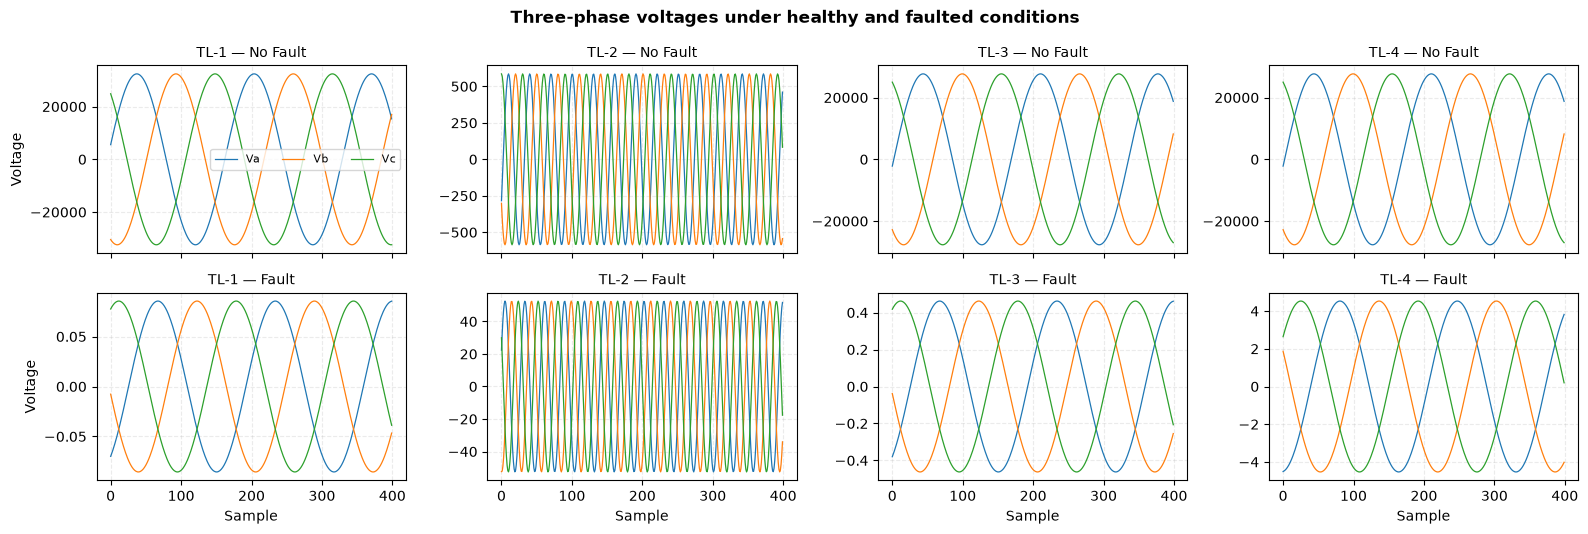

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 5.4), sharex=True)
for j, c in enumerate(CASES):
    X, y, t = load_case(c)
    nf = np.flatnonzero(y == 0)[:400]
    fa = np.flatnonzero(y == 1)[:400]
    for ax, idx, ttl in [(axes[0, j], nf, 'No Fault'), (axes[1, j], fa, 'Fault')]:
        for k in range(3):
            ax.plot(X[idx, k], lw=0.9, label=f'V{"abc"[k]}' if j == 0 else None)
        ax.set_title(f'{c} — {ttl}', fontsize=10)
        ax.grid(alpha=0.25, ls='--')
axes[0, 0].legend(fontsize=8, ncol=3)
axes[1, 0].set_ylabel('Voltage'); axes[0, 0].set_ylabel('Voltage')
for ax in axes[1]:
    ax.set_xlabel('Sample')
fig.suptitle('Three-phase voltages under healthy and faulted conditions',
             fontweight='bold')
fig.tight_layout(); plt.show()

### 2.5 Descriptors for the non-sequential models

KAN and PSO-ELM take a fixed-length vector rather than a sequence. Feeding a
flattened window would need `L × 6` inputs and inflate the spline parameter
count, so both consume physics-motivated descriptors instead: per-channel
magnitude, dispersion, waveform shape and spectral content, plus cross-phase
terms — zero-sequence residual current and phase-unbalance ratios — which are
exactly what distinguishes balanced from unbalanced faults.

In [11]:
def handcrafted_features(W):
    """W: (N, L, C) -> (N, D)"""
    N, L, C = W.shape
    f = [W.mean(1), W.std(1),
         np.sqrt((W ** 2).mean(1)),                       # RMS
         W.max(1) - W.min(1),                             # peak-to-peak
         np.abs(W).max(1),                                # crest
         np.abs(np.diff(W, axis=1)).mean(1)]              # mean |slope|
    z = (W - W.mean(1, keepdims=True)) / (W.std(1, keepdims=True) + 1e-8)
    f += [(z ** 3).mean(1), (z ** 4).mean(1)]             # skewness, kurtosis
    f.append((np.diff(np.signbit(W), axis=1) != 0).sum(1).astype(np.float32))
    S = np.abs(np.fft.rfft(W - W.mean(1, keepdims=True), axis=1))
    for i in range(1, min(6, S.shape[1])):
        f.append(S[:, i, :] / (S[:, 1:, :].sum(1) + 1e-8))  # normalised harmonics
    F = np.concatenate(f, axis=1)

    rms = np.sqrt((W ** 2).mean(1)); v, i_ = rms[:, :3], rms[:, 3:]
    extra = np.stack([
        v.std(1) / (v.mean(1) + 1e-8), i_.std(1) / (i_.mean(1) + 1e-8),   # unbalance
        v.max(1) / (v.min(1) + 1e-8), i_.max(1) / (i_.min(1) + 1e-8),
        i_.mean(1) / (v.mean(1) + 1e-8),                                  # admittance proxy
        np.abs(W[:, :, 3:].sum(2)).mean(1),                               # residual current
        np.abs(W[:, :, :3].sum(2)).mean(1),                               # residual voltage
    ], axis=1)
    return np.nan_to_num(np.concatenate([F, extra], axis=1)).astype(np.float32)


F_train, F_val, F_test = (handcrafted_features(a) for a in (X_train, X_val, X_test))
fmu, fsd = F_train.mean(0), F_train.std(0) + 1e-8
F_train_s, F_val_s, F_test_s = ((a - fmu) / fsd for a in (F_train, F_val, F_test))
N_DESC = F_train.shape[1]
print(f'descriptor dimension: {N_DESC}')

descriptor dimension: 91


## 3. Models

### 3.1 MS4 / MS4N — diagonal structured state space model (S4D)

The continuous LTI system `h'(t) = Ah + Bx`, `y = Ch + Dx` with `A` constrained
diagonal. Each eigenvalue is `λₙ = −exp(aₙ) + i·bₙ`, so `Re(λₙ) < 0` guarantees
a stable fading memory. Zero-order hold gives `Ā = exp(ΔΛ)`,
`B̄ = Λ⁻¹(Ā − I)B`, and the recurrence becomes a global convolution with kernel
`K = [C Ā⁰B̄, …, C Ā^{L−1}B̄]`, evaluated by FFT in `O(L log L)`.

**MS4** adds a learnable input projection (`F → H`) and gated channel mixing
(`H → 2H`, split, `a ⊙ σ(b)`). **MS4N** adds one LayerNorm — under 0.3% of
parameters, and per the source paper the single largest contributor to its gains.

In [12]:
class S4DKernel(nn.Module):
    """Diagonal SSM kernel with S4D-Lin initialisation (imaginary part = πn)."""
    def __init__(self, d_model, d_state=64, dt_min=1e-3, dt_max=1e-1):
        super().__init__()
        H, N = d_model, d_state // 2
        log_dt = torch.rand(H) * (math.log(dt_max) - math.log(dt_min)) + math.log(dt_min)
        self.log_dt     = nn.Parameter(log_dt)
        self.C          = nn.Parameter(torch.randn(H, N, 2) * 0.5 ** 0.5)
        self.log_A_real = nn.Parameter(torch.log(0.5 * torch.ones(H, N)))
        self.A_imag     = nn.Parameter(math.pi * torch.arange(N).repeat(H, 1).float())

    def forward(self, L):
        dt = torch.exp(self.log_dt).unsqueeze(-1)                 # (H,1)
        A  = -torch.exp(self.log_A_real) + 1j * self.A_imag       # (H,N), Re<0 => stable
        C  = torch.view_as_complex(self.C)
        dtA = A * dt                                              # ZOH
        Cb  = C * (torch.exp(dtA) - 1.0) / A                      # B absorbed into C
        K   = dtA.unsqueeze(-1) * torch.arange(L, device=A.device)
        return 2.0 * torch.einsum('hn,hnl->hl', Cb, torch.exp(K)).real


class S4D(nn.Module):
    """y = (K * x) + D·x, then GELU + dropout. Convolution via FFT."""
    def __init__(self, d_model, d_state=64, dropout=0.1):
        super().__init__()
        self.kernel = S4DKernel(d_model, d_state)
        self.D = nn.Parameter(torch.randn(d_model))
        self.drop = nn.Dropout(dropout)

    def forward(self, u):                        # (B, H, L)
        L = u.size(-1)
        k_f = torch.fft.rfft(self.kernel(L), n=2 * L)
        u_f = torch.fft.rfft(u, n=2 * L)
        y = torch.fft.irfft(u_f * k_f, n=2 * L)[..., :L]
        y = y + u * self.D.unsqueeze(-1)         # feed-through / skip
        return self.drop(Fn.gelu(y))


class MS4(nn.Module):
    """MS4 = S4D + input projection + gated channel mixing.
       MS4N = MS4 + LayerNorm (normalize=True)."""
    def __init__(self, n_features, n_classes=2, d_model=64, d_state=64,
                 normalize=True, dropout=0.1, n_layers=1):
        super().__init__()
        self.inp    = nn.Linear(n_features, d_model)                # F -> H
        self.blocks = nn.ModuleList([S4D(d_model, d_state, dropout)
                                     for _ in range(n_layers)])
        self.mix    = nn.Linear(d_model, 2 * d_model)               # GLU: H -> 2H
        self.norm   = nn.LayerNorm(d_model) if normalize else nn.Identity()
        self.head   = nn.Sequential(nn.Linear(d_model, d_model), nn.GELU(),
                                    nn.Linear(d_model, n_classes))

    def forward(self, x):                        # (B, L, F)
        h = self.inp(x).transpose(1, 2)          # (B, H, L)
        for blk in self.blocks:
            h = blk(h)
        h = h.transpose(1, 2)
        a, b = self.mix(h).chunk(2, dim=-1)
        g = self.norm(a * torch.sigmoid(b))      # gated channel mixing (+LayerNorm)
        return self.head(g.mean(dim=1))          # global average pooling

### 3.2 Mamba-2 — input-dependent SSM

Unlike S4D's fixed dynamics, Mamba conditions the state transition, input
projection and step size on the input at each timestep. This uses the **State
Space Duality** form: with a scalar decay per head, the recurrence
`hₜ = aₜhₜ₋₁ + Δₜ Bₜ xₜ` expands to
`yₜ = Σ_{s≤t} (∏_{r=s+1..t} aᵣ) Cₜ·B_s Δ_s x_s`, computable in parallel as a
masked `L × L` matrix. Mathematically identical to the sequential scan, but
roughly 3× faster here.

In [13]:
class Mamba2Block(nn.Module):
    def __init__(self, d_model, d_state=32, expand=2, n_heads=4, d_conv=4):
        super().__init__()
        self.d_inner = d_model * expand
        self.n_heads, self.d_state = n_heads, d_state
        self.hdim = self.d_inner // n_heads
        self.in_proj = nn.Linear(d_model, 2 * self.d_inner + 2 * d_state + n_heads)
        self.conv = nn.Conv1d(self.d_inner, self.d_inner, d_conv,
                              groups=self.d_inner, padding=d_conv - 1)
        self.dt_bias = nn.Parameter(torch.log(torch.rand(n_heads) * 0.09 + 0.001))
        self.A_log   = nn.Parameter(torch.log(torch.arange(1, n_heads + 1).float()))
        self.D       = nn.Parameter(torch.ones(n_heads))
        self.norm    = nn.LayerNorm(self.d_inner)
        self.out_proj = nn.Linear(self.d_inner, d_model)

    def forward(self, x):                        # (B, L, D)
        B, L, _ = x.shape
        z, xc, Bm, Cm, dt = torch.split(
            self.in_proj(x),
            [self.d_inner, self.d_inner, self.d_state, self.d_state, self.n_heads], dim=-1)
        xc = Fn.silu(self.conv(xc.transpose(1, 2))[..., :L].transpose(1, 2))
        dt = Fn.softplus(dt + self.dt_bias)                      # input-dependent step
        A  = -torch.exp(self.A_log)
        xh = xc.view(B, L, self.n_heads, self.hdim)

        dA = (dt * A).transpose(1, 2)                            # (B,Hd,L) log-decay
        cs = torch.cumsum(dA, dim=-1)
        decay = cs.unsqueeze(-1) - cs.unsqueeze(-2)              # log decay ratio
        causal = torch.ones(L, L, device=x.device, dtype=torch.bool).tril()
        decay = torch.where(causal, decay, torch.full_like(decay, float('-inf')))
        CB = torch.einsum('bln,bsn->bls', Cm, Bm).unsqueeze(1)
        M  = CB * torch.exp(decay)
        dx = (dt.unsqueeze(-1) * xh).permute(0, 2, 1, 3)
        y  = torch.einsum('bhls,bhsp->bhlp', M, dx)
        y  = y + self.D.view(1, -1, 1, 1) * xh.permute(0, 2, 1, 3)
        y  = y.permute(0, 2, 1, 3).reshape(B, L, self.d_inner)
        return self.out_proj(self.norm(y) * Fn.silu(z))


class Mamba2Classifier(nn.Module):
    def __init__(self, n_features, n_classes=2, d_model=48, d_state=32, n_layers=2):
        super().__init__()
        self.inp    = nn.Linear(n_features, d_model)
        self.layers = nn.ModuleList([Mamba2Block(d_model, d_state) for _ in range(n_layers)])
        self.norms  = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(n_layers)])
        self.head   = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, n_classes))

    def forward(self, x):
        h = self.inp(x)
        for blk, nrm in zip(self.layers, self.norms):
            h = h + blk(nrm(h))                  # pre-norm residual
        return self.head(h.mean(1))

### 3.3 Kolmogorov–Arnold Network

KAN replaces fixed activations on nodes with learnable univariate functions on
edges. Each edge is a B-spline over a fixed grid, plus a SiLU residual branch.
Inputs are squashed with `tanh` so they stay inside the spline grid range.

In [14]:
class KANLinear(nn.Module):
    def __init__(self, in_f, out_f, grid_size=5, k=3, grid_range=(-2.0, 2.0)):
        super().__init__()
        self.in_f, self.out_f, self.grid_size, self.k = in_f, out_f, grid_size, k
        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = torch.arange(-k, grid_size + k + 1) * h + grid_range[0]
        self.register_buffer('grid', grid.expand(in_f, -1).contiguous())
        self.base_w   = nn.Parameter(torch.empty(out_f, in_f))
        self.spline_w = nn.Parameter(torch.empty(out_f, in_f, grid_size + k))
        nn.init.kaiming_uniform_(self.base_w, a=math.sqrt(5))
        nn.init.normal_(self.spline_w, 0.0, 0.1 / math.sqrt(in_f))

    def b_splines(self, x):                      # (B,in_f) -> (B,in_f,G+k)
        g = self.grid; x = x.unsqueeze(-1)
        bases = ((x >= g[:, :-1]) & (x < g[:, 1:])).to(x.dtype)
        for p in range(1, self.k + 1):           # Cox-de Boor recursion
            bases = ((x - g[:, :-(p+1)]) / (g[:, p:-1] - g[:, :-(p+1)]) * bases[:, :, :-1]
                     + (g[:, p+1:] - x) / (g[:, p+1:] - g[:, 1:-p]) * bases[:, :, 1:])
        return bases.contiguous()

    def forward(self, x):
        base = Fn.linear(Fn.silu(x), self.base_w)
        spl  = Fn.linear(self.b_splines(x).view(x.size(0), -1),
                         self.spline_w.view(self.out_f, -1))
        return base + spl


class KANClassifier(nn.Module):
    def __init__(self, n_features, n_classes=2, hidden=(32, 16), grid_size=5):
        super().__init__()
        dims = [n_features, *hidden, n_classes]
        self.norm = nn.BatchNorm1d(n_features)
        self.layers = nn.ModuleList([KANLinear(dims[i], dims[i+1], grid_size=grid_size)
                                     for i in range(len(dims) - 1)])

    def forward(self, x):
        h = torch.tanh(self.norm(x))             # keep inputs inside the spline grid
        for i, lyr in enumerate(self.layers):
            h = lyr(h)
            if i < len(self.layers) - 1:
                h = torch.tanh(h)
        return h

### 3.4 LSTM and LRCN

In [15]:
class LSTMClassifier(nn.Module):
    def __init__(self, n_features, n_classes=2, hidden=64, n_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, n_layers, batch_first=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.head = nn.Sequential(nn.LayerNorm(hidden), nn.Dropout(dropout),
                                  nn.Linear(hidden, n_classes))

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1])


class LRCN(nn.Module):
    """Long-term Recurrent Convolutional Network: Conv1D feature extractor
    feeding a recurrent temporal model."""
    def __init__(self, n_features, n_classes=2, ch=(32, 64), hidden=64, dropout=0.2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(n_features, ch[0], 7, padding=3), nn.BatchNorm1d(ch[0]), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(ch[0], ch[1], 5, padding=2), nn.BatchNorm1d(ch[1]), nn.ReLU(),
            nn.MaxPool1d(2), nn.Dropout(dropout))
        self.lstm = nn.LSTM(ch[1], hidden, batch_first=True)
        self.head = nn.Sequential(nn.LayerNorm(hidden), nn.Dropout(dropout),
                                  nn.Linear(hidden, n_classes))

    def forward(self, x):
        h = self.cnn(x.transpose(1, 2)).transpose(1, 2)
        out, _ = self.lstm(h)
        return self.head(out[:, -1])

### 3.5 PSO — Particle Swarm Optimisation

PSO drives an Extreme Learning Machine. Each particle encodes a binary feature
mask plus three continuous hyper-parameters (hidden width, input-weight scale,
ridge penalty); ELM output weights have a closed-form ridge solution, so one
fitness evaluation is a single least-squares solve. That is what makes a full
swarm search tractable — an SVM or back-propagated MLP inner loop would need
hundreds of full fits.

Velocity update: `v ← w·v + c₁r₁(pbest − x) + c₂r₂(gbest − x)`, with fitness =
validation F1 minus a small parsimony penalty favouring compact feature subsets.

In [16]:
class PSOELM:
    def __init__(self, n_particles=30, n_iter=40, w=0.72, c1=1.49, c2=1.49,
                 h_range=(32, 256), seed=SEED):
        self.n_particles, self.n_iter = n_particles, n_iter
        self.w, self.c1, self.c2 = w, c1, c2
        self.h_range, self.rng = h_range, np.random.default_rng(seed)
        self.history_ = []

    def _decode(self, p, D):
        mask = p[:D] > 0.5
        if mask.sum() < 3:
            mask[self.rng.choice(D, 3, replace=False)] = True
        h     = int(self.h_range[0] + p[D] * (self.h_range[1] - self.h_range[0]))
        scale = 10 ** (-1 + 2 * p[D+1])          # 0.1 .. 10
        lam   = 10 ** (-6 + 6 * p[D+2])          # 1e-6 .. 1
        return mask, h, scale, lam

    def _fit_elm(self, X, y, mask, h, scale, lam, seed):
        rng = np.random.default_rng(seed)
        Xm = X[:, mask]
        W = rng.normal(0, scale, (Xm.shape[1], h)); b = rng.normal(0, scale, h)
        H = np.tanh(Xm @ W + b)
        beta = np.linalg.solve(H.T @ H + lam * np.eye(h), H.T @ np.eye(2)[y])
        return W, b, beta

    @staticmethod
    def _f1(y, p):
        tp = np.sum((p == 1) & (y == 1)); fp = np.sum((p == 1) & (y == 0))
        fn = np.sum((p == 0) & (y == 1))
        return 2 * tp / max(2 * tp + fp + fn, 1)

    def _score(self, Xtr, ytr, Xva, yva, p, seed=0):
        mask, h, scale, lam = self._decode(p, Xtr.shape[1])
        try:
            W, b, beta = self._fit_elm(Xtr, ytr, mask, h, scale, lam, seed)
            pred = (np.tanh(Xva[:, mask] @ W + b) @ beta).argmax(1)
        except np.linalg.LinAlgError:
            return 0.0
        return self._f1(yva, pred) - 0.01 * mask.mean()      # parsimony pressure

    def fit(self, Xtr, ytr, Xva, yva, verbose=True):
        D = Xtr.shape[1]; dim = D + 3
        X = self.rng.random((self.n_particles, dim))
        V = self.rng.normal(0, 0.1, (self.n_particles, dim))
        pbest = X.copy()
        pbest_s = np.array([self._score(Xtr, ytr, Xva, yva, x) for x in X])
        g = int(pbest_s.argmax()); gbest, gbest_s = pbest[g].copy(), pbest_s[g]
        for it in range(self.n_iter):
            r1, r2 = self.rng.random((2, self.n_particles, dim))
            V = self.w * V + self.c1 * r1 * (pbest - X) + self.c2 * r2 * (gbest - X)
            V = np.clip(V, -0.3, 0.3)
            X = np.clip(X + V, 0, 1)
            s = np.array([self._score(Xtr, ytr, Xva, yva, x) for x in X])
            imp = s > pbest_s
            pbest[imp], pbest_s[imp] = X[imp], s[imp]
            if pbest_s.max() > gbest_s:
                g = int(pbest_s.argmax()); gbest, gbest_s = pbest[g].copy(), pbest_s[g]
            self.history_.append(gbest_s)
            if verbose and (it % 5 == 0 or it == self.n_iter - 1):
                print(f'    PSO iter {it:3d}   global-best fitness = {gbest_s:.4f}')
        self.mask_, self.h_, self.scale_, self.lam_ = self._decode(gbest, D)
        self.W_, self.b_, self.beta_ = self._fit_elm(
            np.vstack([Xtr, Xva]), np.concatenate([ytr, yva]),
            self.mask_, self.h_, self.scale_, self.lam_, seed=0)
        return self

    def decision_scores(self, X):
        Z = np.tanh(X[:, self.mask_] @ self.W_ + self.b_) @ self.beta_
        e = np.exp(Z - Z.max(1, keepdims=True))
        return e / e.sum(1, keepdims=True)

    def predict(self, X):
        return self.decision_scores(X).argmax(1)


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

### 3.6 ANN — plain feed-forward baseline

A conventional multi-layer perceptron on the same handcrafted descriptors used
by KAN and PSO-ELM: fixed ReLU activations on the nodes (rather than KAN's
learnable edge splines), batch normalisation, and dropout. This is the
"vanilla neural network" reference point — it isolates how much of KAN's
behaviour comes from the descriptor representation itself versus its
spline-based edges.


In [17]:
class ANNClassifier(nn.Module):
    """Plain feed-forward MLP baseline on handcrafted descriptors."""
    def __init__(self, n_features, n_classes=2, hidden=(64, 32, 16), dropout=0.2):
        super().__init__()
        self.norm = nn.BatchNorm1d(n_features)
        dims = [n_features, *hidden]
        layers = []
        for a, b in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(a, b), nn.BatchNorm1d(b), nn.ReLU(), nn.Dropout(dropout)]
        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(dims[-1], n_classes)

    def forward(self, x):
        h = self.norm(x)
        h = self.body(h)
        return self.head(h)


## 4. Training protocol

One protocol for every neural baseline, so differences reflect architecture and
not tuning: AdamW at 1e-3 with cosine decay, class-weighted cross-entropy
(the test set is ~92% fault), gradient clipping at 1.0, early stopping on
validation **macro**-F1, and best-checkpoint restore.

In [18]:
from torch.utils.data import TensorDataset, DataLoader

def train_torch(model, Xtr, ytr, Xva, yva, epochs=EPOCHS, lr=LR,
                batch_size=BATCH_SIZE, patience=PATIENCE, device=DEVICE,
                verbose=True, seed=SEED):
    set_seed(seed)
    model = model.to(device)
    tr_dl = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)),
                       batch_size=batch_size, shuffle=True)
    va_dl = DataLoader(TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva)),
                       batch_size=512, shuffle=False)
    cnt = np.bincount(ytr, minlength=2)
    w = torch.tensor(cnt.sum() / (2 * np.maximum(cnt, 1)), dtype=torch.float32, device=device)
    crit  = nn.CrossEntropyLoss(weight=w)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    hist = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_acc': []}
    best, best_state, bad = -1.0, None, 0
    t0 = time.time()
    for ep in range(epochs):
        model.train(); tot = n = 0
        for xb, yb in tr_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tot += loss.item() * len(yb); n += len(yb)
        model.eval(); vl = m = 0; P, T = [], []
        with torch.no_grad():
            for xb, yb in va_dl:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                vl += crit(out, yb).item() * len(yb); m += len(yb)
                P.append(out.argmax(1).cpu().numpy()); T.append(yb.cpu().numpy())
        P, T = np.concatenate(P), np.concatenate(T)
        f1 = f1_score(T, P, average='macro', zero_division=0)
        hist['train_loss'].append(tot/n); hist['val_loss'].append(vl/m)
        hist['val_f1'].append(f1); hist['val_acc'].append(accuracy_score(T, P))
        sched.step()
        if f1 > best:
            best, bad = f1, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
        if verbose and (ep % 5 == 0 or ep == epochs - 1):
            print(f'    epoch {ep:3d}   train {tot/n:.4f}   val {vl/m:.4f}   '
                  f'val macro-F1 {f1:.4f}')
        if bad >= patience:
            if verbose:
                print(f'    early stop @ epoch {ep} (best macro-F1 {best:.4f})')
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, hist, time.time() - t0


@torch.no_grad()
def predict_torch(model, X, batch_size=512, device=DEVICE):
    model.eval().to(device)
    P, S = [], []
    for i in range(0, len(X), batch_size):
        out = model(torch.from_numpy(X[i:i+batch_size]).to(device))
        p = torch.softmax(out, 1).cpu().numpy()
        S.append(p); P.append(p.argmax(1))
    return np.concatenate(P), np.concatenate(S)

### 4.1 Metrics

Positive class is **Fault**. Alongside the four requested metrics, the table
reports specificity and — for a protection relay, the two that matter
operationally — missed-detection rate and false-alarm rate.

In [19]:
def evaluate(y_true, y_pred, y_prob=None):
    m = {
        'Accuracy':          accuracy_score(y_true, y_pred),
        'Balanced Acc':      balanced_accuracy_score(y_true, y_pred),
        'Precision':         precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Recall':            recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'F1-score':          f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Precision (macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (macro)':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 (macro)':        f1_score(y_true, y_pred, average='macro', zero_division=0),
        'MCC':               matthews_corrcoef(y_true, y_pred),
    }
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    m['Specificity']           = tn / max(tn + fp, 1)
    m['Missed Detection Rate'] = fn / max(fn + tp, 1)
    m['False Alarm Rate']      = fp / max(fp + tn, 1)
    if y_prob is not None and len(np.unique(y_true)) > 1:
        m['ROC-AUC'] = roc_auc_score(y_true, y_prob[:, 1])
    return m, cm

## 5. Run the benchmark

In [20]:
results, cms, rocs, hists, preds = {}, {}, {}, {}, {}

SEQ_MODELS = {
    'MS4N (S4D)': lambda: MS4(N_FEATS, d_model=64, d_state=64, normalize=True),
    'MS4 (S4D)':  lambda: MS4(N_FEATS, d_model=64, d_state=64, normalize=False),
    'Mamba-2':    lambda: Mamba2Classifier(N_FEATS, d_model=48, d_state=32, n_layers=2),
    'LSTM':       lambda: LSTMClassifier(N_FEATS, hidden=64, n_layers=2),
    'LRCN':       lambda: LRCN(N_FEATS),
}

for name, ctor in SEQ_MODELS.items():
    print(f'\n=== {name} ===')
    model, hist, tt = train_torch(ctor(), X_train, y_train, X_val, y_val)
    yp, ps = predict_torch(model, X_test)
    met, cm = evaluate(y_test, yp, ps)
    met['Params'] = count_params(model); met['Train time (s)'] = tt
    results[name], cms[name], hists[name], preds[name] = met, cm, hist, yp
    fpr, tpr, _ = roc_curve(y_test, ps[:, 1]); rocs[name] = (fpr, tpr, met['ROC-AUC'])
    print(f'  test accuracy {met["Accuracy"]:.4f}   F1 {met["F1-score"]:.4f}   ({tt:.0f}s)')


=== MS4N (S4D) ===
    epoch   0   train 0.3189   val 0.0963   val macro-F1 0.9152
    epoch   5   train 0.0730   val 0.0574   val macro-F1 0.9473
    epoch  10   train 0.0480   val 0.1346   val macro-F1 0.9632
    epoch  15   train 0.0404   val 0.0513   val macro-F1 0.9529
    epoch  20   train 0.0266   val 0.0451   val macro-F1 0.9799
    epoch  25   train 0.0220   val 0.0352   val macro-F1 0.9719
    early stop @ epoch 28 (best macro-F1 0.9799)
  test accuracy 0.9902   F1 0.9946   (38s)

=== MS4 (S4D) ===
    epoch   0   train 0.4838   val 0.1659   val macro-F1 0.8745
    epoch   5   train 0.0984   val 0.0856   val macro-F1 0.8898
    epoch  10   train 0.0554   val 0.0484   val macro-F1 0.9556
    epoch  15   train 0.0365   val 0.0489   val macro-F1 0.9343
    epoch  20   train 0.0268   val 0.0296   val macro-F1 0.9646
    early stop @ epoch 24 (best macro-F1 0.9736)
  test accuracy 0.9888   F1 0.9939   (30s)

=== Mamba-2 ===
    epoch   0   train 0.2057   val 0.0827   val macro-F1

In [21]:
print('=== KAN ===')
model, hist, tt = train_torch(KANClassifier(N_DESC, hidden=(32, 16)),
                              F_train_s, y_train, F_val_s, y_val)
yp, ps = predict_torch(model, F_test_s)
met, cm = evaluate(y_test, yp, ps)
met['Params'] = count_params(model); met['Train time (s)'] = tt
results['KAN'], cms['KAN'], hists['KAN'], preds['KAN'] = met, cm, hist, yp
fpr, tpr, _ = roc_curve(y_test, ps[:, 1]); rocs['KAN'] = (fpr, tpr, met['ROC-AUC'])
print(f'  test accuracy {met["Accuracy"]:.4f}   F1 {met["F1-score"]:.4f}   ({tt:.0f}s)')

=== KAN ===
    epoch   0   train 0.2868   val 0.0744   val macro-F1 0.9212
    epoch   5   train 0.0281   val 0.0196   val macro-F1 0.9898
    epoch  10   train 0.0154   val 0.0151   val macro-F1 0.9942
    epoch  15   train 0.0096   val 0.0058   val macro-F1 0.9928
    epoch  20   train 0.0069   val 0.0047   val macro-F1 0.9957
    epoch  25   train 0.0063   val 0.0048   val macro-F1 0.9943
    early stop @ epoch 28 (best macro-F1 0.9957)
  test accuracy 0.9943   F1 0.9969   (31s)


In [22]:
print('=== PSO-ELM ===')
t0 = time.time()
pso = PSOELM(n_particles=25, n_iter=30).fit(F_train_s, y_train, F_val_s, y_val)
tt = time.time() - t0
ps = pso.decision_scores(F_test_s); yp = ps.argmax(1)
met, cm = evaluate(y_test, yp, ps)
met['Params'] = int(pso.mask_.sum() * pso.h_ + pso.h_ + 2 * pso.h_)
met['Train time (s)'] = tt
results['PSO-ELM'], cms['PSO-ELM'], preds['PSO-ELM'] = met, cm, yp
fpr, tpr, _ = roc_curve(y_test, ps[:, 1]); rocs['PSO-ELM'] = (fpr, tpr, met['ROC-AUC'])
print(f'  selected {int(pso.mask_.sum())}/{N_DESC} descriptors, {pso.h_} hidden neurons')
print(f'  test accuracy {met["Accuracy"]:.4f}   F1 {met["F1-score"]:.4f}   ({tt:.0f}s)')

=== PSO-ELM ===
    PSO iter   0   global-best fitness = 0.9867
    PSO iter   5   global-best fitness = 0.9877
    PSO iter  10   global-best fitness = 0.9877
    PSO iter  15   global-best fitness = 0.9884
    PSO iter  20   global-best fitness = 0.9890
    PSO iter  25   global-best fitness = 0.9890
    PSO iter  29   global-best fitness = 0.9890
  selected 39/91 descriptors, 195 hidden neurons
  test accuracy 0.9739   F1 0.9860   (42s)


In [23]:
print('=== ANN ===')
model, hist, tt = train_torch(ANNClassifier(N_DESC, hidden=(64, 32, 16)),
                              F_train_s, y_train, F_val_s, y_val)
yp, ps = predict_torch(model, F_test_s)
met, cm = evaluate(y_test, yp, ps)
met['Params'] = count_params(model); met['Train time (s)'] = tt
results['ANN'], cms['ANN'], hists['ANN'], preds['ANN'] = met, cm, hist, yp
fpr, tpr, _ = roc_curve(y_test, ps[:, 1]); rocs['ANN'] = (fpr, tpr, met['ROC-AUC'])
print(f'  test accuracy {met["Accuracy"]:.4f}   F1 {met["F1-score"]:.4f}   ({tt:.0f}s)')


=== ANN ===
    epoch   0   train 0.4008   val 0.2289   val macro-F1 0.8464
    epoch   5   train 0.0611   val 0.0301   val macro-F1 0.9531
    epoch  10   train 0.0401   val 0.0200   val macro-F1 0.9669
    epoch  15   train 0.0272   val 0.0124   val macro-F1 0.9818
    epoch  20   train 0.0211   val 0.0125   val macro-F1 0.9844
    epoch  25   train 0.0229   val 0.0111   val macro-F1 0.9872
    epoch  29   train 0.0149   val 0.0101   val macro-F1 0.9873
  test accuracy 0.9939   F1 0.9967   (9s)


## 6. Results table

In [24]:
ORDER = ['MS4N (S4D)', 'MS4 (S4D)', 'Mamba-2', 'KAN', 'ANN', 'PSO-ELM', 'LSTM', 'LRCN']
ORDER = [m for m in ORDER if m in results]
df = pd.DataFrame(results).T.loc[ORDER]
df.to_csv(f'{OUT_DIR}/results_fault_detection.csv')

MAIN = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Specificity', 'ROC-AUC',
        'Missed Detection Rate', 'False Alarm Rate', 'Params', 'Train time (s)']
display(df[[c for c in MAIN if c in df.columns]]
        .style.format({**{c: '{:.4f}' for c in MAIN if c not in ('Params',)},
                       'Params': '{:,.0f}'})
        .background_gradient(subset=['Accuracy', 'F1-score'], cmap='Greens')
        .set_caption('Binary fault detection — held-out test set'))

,Accuracy,Precision,Recall,F1-score,Specificity,ROC-AUC,Missed Detection Rate,False Alarm Rate,Params,Train time (s)
MS4N (S4D),0.9902,0.9970,0.9923,0.9946,0.9670,0.9993,0.0077,0.0330,"21,506",37.5701
MS4 (S4D),0.9888,0.9981,0.9897,0.9939,0.9788,0.9992,0.0103,0.0212,"21,378",30.3214
Mamba-2,0.9926,0.9945,0.9974,0.9959,0.9387,0.9992,0.0026,0.0613,"36,882",73.0916
KAN,0.9943,0.9989,0.9949,0.9969,0.9882,0.9997,0.0051,0.0118,"31,286",31.2407
ANN,0.9939,0.9994,0.9940,0.9967,0.9929,0.9996,0.0060,0.0071,"8,936",9.1141
PSO-ELM,0.9739,0.9739,0.9983,0.9860,0.7052,0.9937,0.0017,0.2948,"8,190",41.6127
LSTM,0.9906,0.9961,0.9936,0.9949,0.9575,0.9984,0.0064,0.0425,"51,970",47.8194
LRCN,0.9922,0.9970,0.9944,0.9957,0.9670,0.9988,0.0056,0.0330,"45,410",22.1402


In [25]:
# LaTeX table, ready to paste into the paper
tex = df[['Accuracy', 'Precision', 'Recall', 'F1-score', 'Params']].copy()
tex['Params'] = tex['Params'].map(lambda v: f'{int(v):,}')
print(tex.to_latex(float_format='%.4f', caption='Fault detection performance.',
                   label='tab:detection', column_format='lrrrrr'))

\begin{table}
\caption{Fault detection performance.}
\label{tab:detection}
\begin{tabular}{lrrrrr}
\toprule
 & Accuracy & Precision & Recall & F1-score & Params \\
\midrule
MS4N (S4D) & 0.9902 & 0.9970 & 0.9923 & 0.9946 & 21,506 \\
MS4 (S4D) & 0.9888 & 0.9981 & 0.9897 & 0.9939 & 21,378 \\
Mamba-2 & 0.9926 & 0.9945 & 0.9974 & 0.9959 & 36,882 \\
KAN & 0.9943 & 0.9989 & 0.9949 & 0.9969 & 31,286 \\
ANN & 0.9939 & 0.9994 & 0.9940 & 0.9967 & 8,936 \\
PSO-ELM & 0.9739 & 0.9739 & 0.9983 & 0.9860 & 8,190 \\
LSTM & 0.9906 & 0.9961 & 0.9936 & 0.9949 & 51,970 \\
LRCN & 0.9922 & 0.9970 & 0.9944 & 0.9957 & 45,410 \\
\bottomrule
\end{tabular}
\end{table}



## 7. Figures

In [26]:
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'serif', 'font.size': 10,
    'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
    'axes.spines.top': False, 'axes.spines.right': False, 'legend.frameon': False,
})
PALETTE = {'MS4N (S4D)': '#2E7D32', 'MS4 (S4D)': '#66BB6A', 'Mamba-2': '#1565C0',
           'KAN': '#8E24AA', 'ANN': '#AD1457', 'PSO-ELM': '#EF6C00',
           'LSTM': '#C62828', 'LRCN': '#00838F'}
col = lambda n: PALETTE.get(n, '#546E7A')

### Figure 1 — Accuracy, Precision, Recall, F1

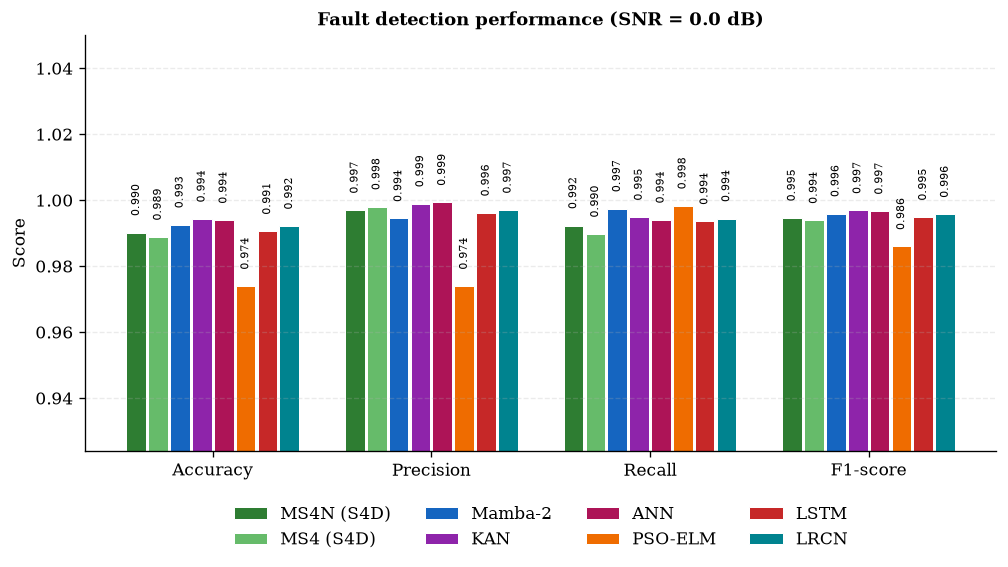

In [27]:
METRICS = ['Accuracy', 'Precision', 'Recall', 'F1-score']
x = np.arange(len(METRICS)); w = 0.8 / len(ORDER)
fig, ax = plt.subplots(figsize=(1.6*len(METRICS) + 3.4, 4.5))
for i, mdl in enumerate(ORDER):
    vals = [df.loc[mdl, k] for k in METRICS]
    pos = x - 0.4 + w * (i + 0.5)
    ax.bar(pos, vals, w*0.9, label=mdl, color=col(mdl), edgecolor='white', lw=0.6)
    for p, v in zip(pos, vals):
        ax.text(p, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=6.3, rotation=90)
lo = df[METRICS].to_numpy().min()
ax.set_xticks(x); ax.set_xticklabels(METRICS)
ax.set_ylim(max(lo - 0.05, 0), 1.05); ax.set_ylabel('Score')
ax.set_title(f'Fault detection performance (SNR = {SNR_DB} dB)')
ax.legend(ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.27))
ax.grid(axis='x', visible=False)
fig.savefig(f'{OUT_DIR}/fig1_metric_comparison.png'); plt.show()

### Figure 2 — Confusion matrices

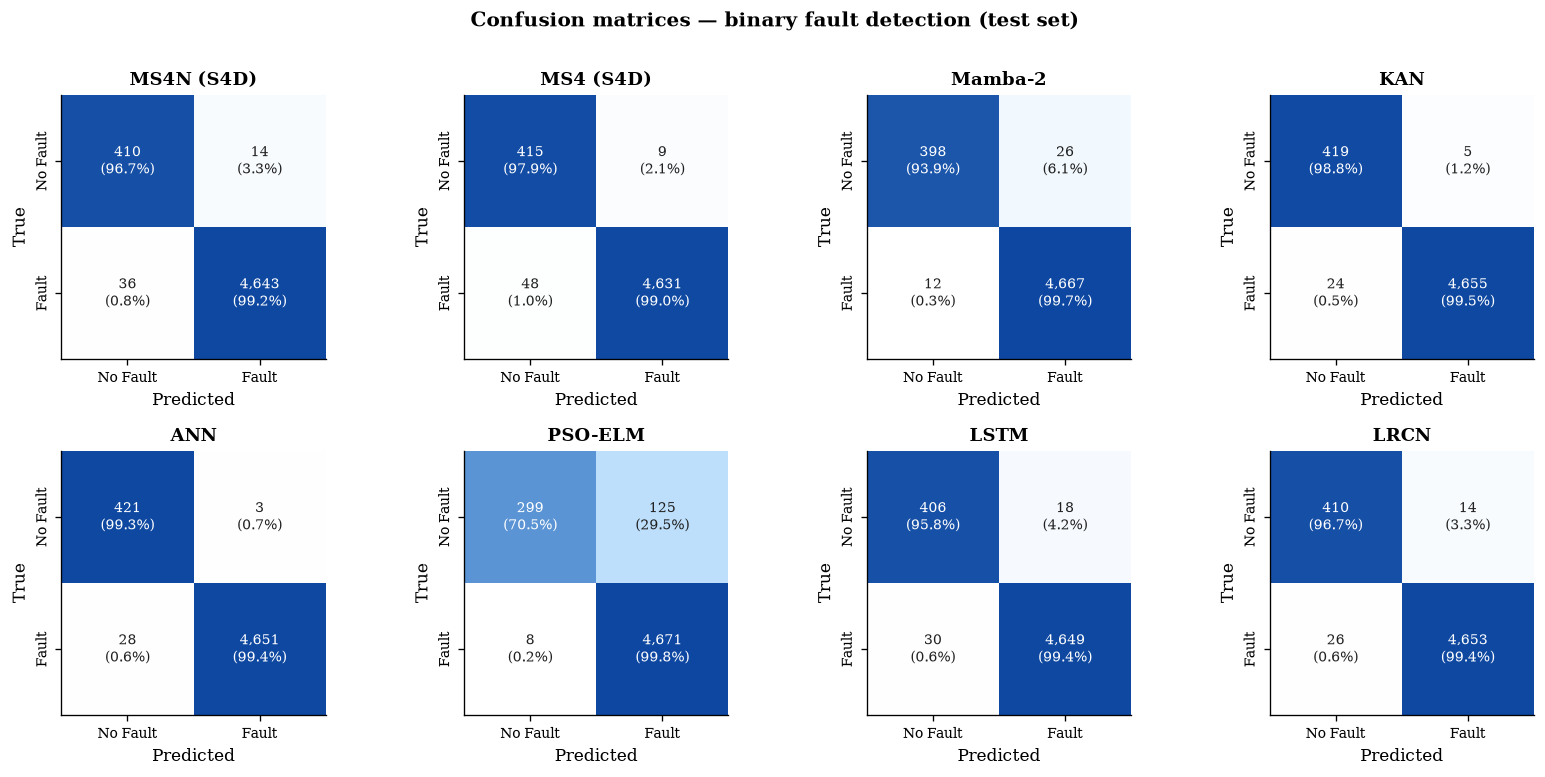

In [28]:
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('bl', ['#FFFFFF', '#90CAF9', '#0D47A1'])
ncols = 4; nrows = int(np.ceil(len(ORDER)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.4*ncols, 3.2*nrows))
axes = np.atleast_1d(axes).ravel()
for ax, name in zip(axes, ORDER):
    cm = cms[name]
    cmn = cm.astype(float) / np.maximum(cm.sum(1, keepdims=True), 1)
    ax.imshow(cmn, cmap=cmap, vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}\n({cmn[i,j]*100:.1f}%)', ha='center', va='center',
                    fontsize=8.5, color='white' if cmn[i,j] > 0.55 else '#212121')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5, rotation=90, va='center')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(name); ax.grid(False)
for ax in axes[len(ORDER):]:
    ax.axis('off')
fig.suptitle('Confusion matrices — binary fault detection (test set)',
             fontweight='bold', y=1.005)
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/fig2_confusion_matrices.png'); plt.show()

### Figure 3 — ROC curves

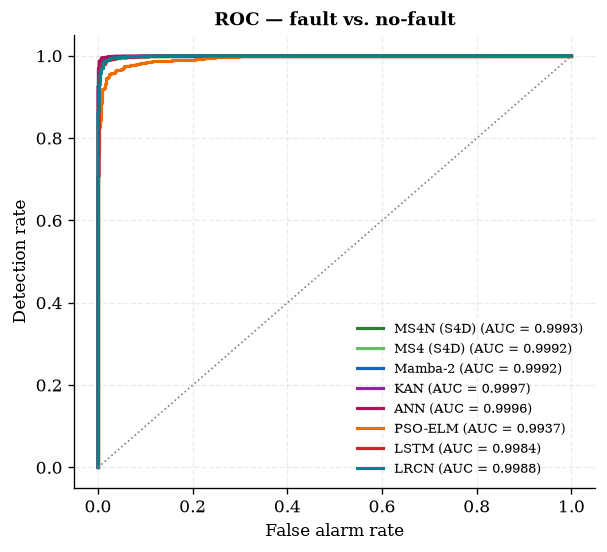

In [29]:
fig, ax = plt.subplots(figsize=(5.6, 4.9))
for name in ORDER:
    fpr, tpr, auc = rocs[name]
    ax.plot(fpr, tpr, lw=1.9, color=col(name), label=f'{name} (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], ls=':', color='grey', lw=1)
ax.set_xlabel('False alarm rate'); ax.set_ylabel('Detection rate')
ax.set_title('ROC — fault vs. no-fault'); ax.legend(loc='lower right', fontsize=8)
fig.savefig(f'{OUT_DIR}/fig3_roc_curves.png'); plt.show()

### Figure 4 — Convergence

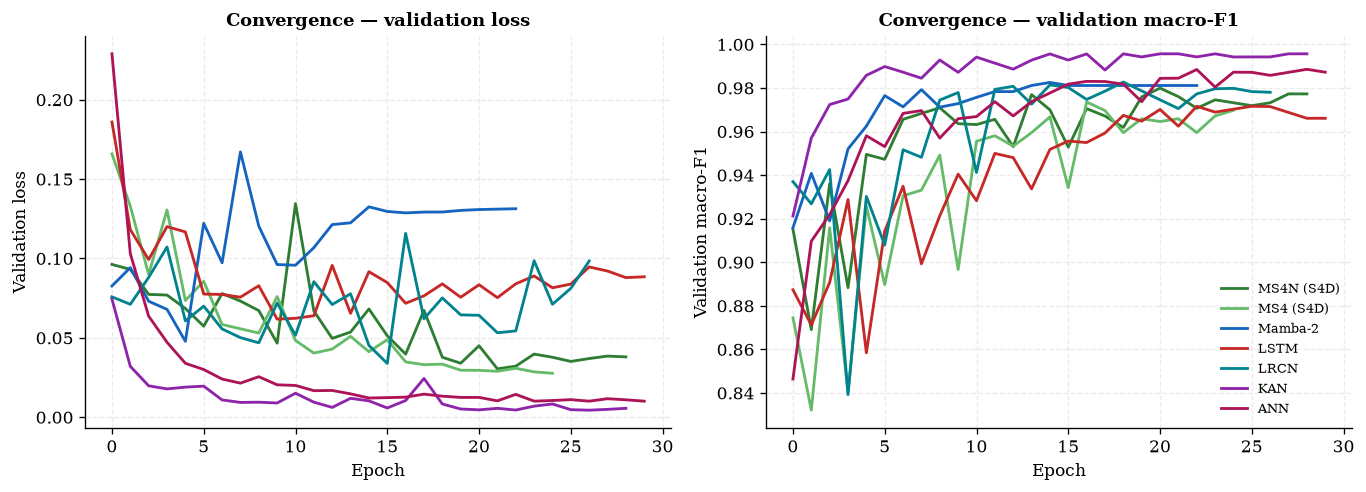

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for name, h in hists.items():
    axes[0].plot(h['val_loss'], color=col(name), lw=1.7, label=name)
    axes[1].plot(h['val_f1'],   color=col(name), lw=1.7, label=name)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation loss')
axes[0].set_title('Convergence — validation loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation macro-F1')
axes[1].set_title('Convergence — validation macro-F1'); axes[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/fig4_training_curves.png'); plt.show()

### Figure 5 — Accuracy vs. complexity

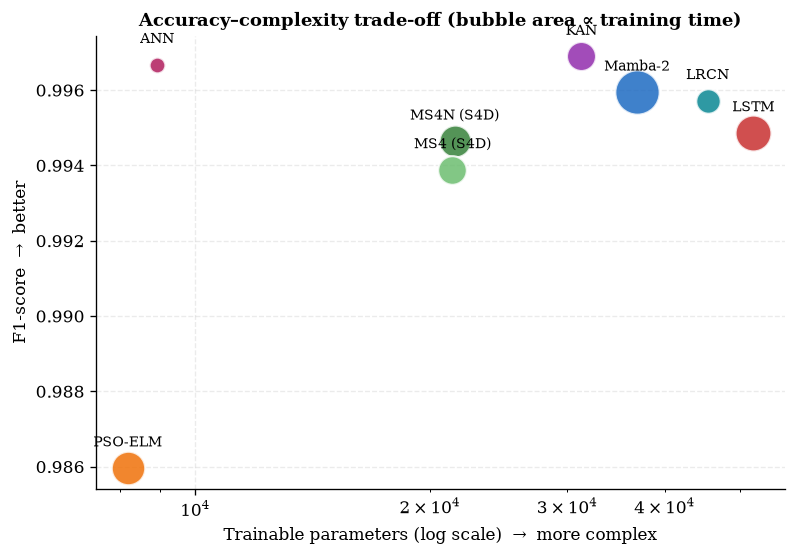

In [31]:
fig, ax = plt.subplots(figsize=(7.4, 4.9))
tt = df['Train time (s)'].to_numpy()
sizes = 90 + 620 * (tt - tt.min()) / (np.ptp(tt) + 1e-9)
for (name, row), s in zip(df.iterrows(), sizes):
    ax.scatter(row['Params'], row['F1-score'], s=s, color=col(name), alpha=0.82,
               edgecolor='white', lw=1.3, zorder=3)
    ax.annotate(name, (row['Params'], row['F1-score']), textcoords='offset points',
                xytext=(0, 13), ha='center', fontsize=8.5)
ax.set_xscale('log')
ax.set_xlabel('Trainable parameters (log scale)  →  more complex')
ax.set_ylabel('F1-score  →  better')
ax.set_title('Accuracy–complexity trade-off (bubble area ∝ training time)')
fig.savefig(f'{OUT_DIR}/fig5_accuracy_complexity.png'); plt.show()

### Figure 6 — Per-configuration accuracy

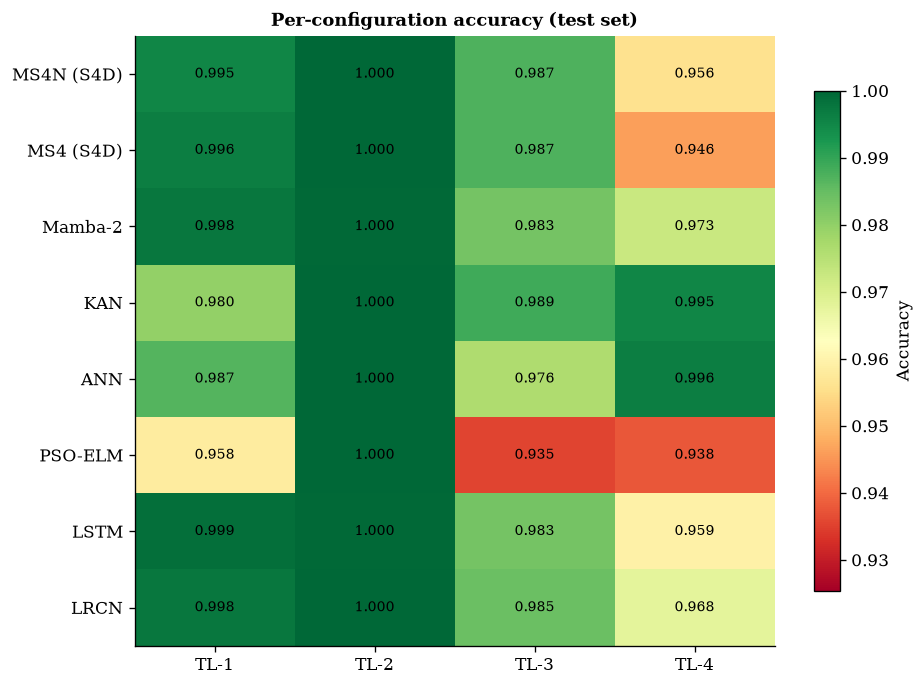

,TL-1,TL-2,TL-3,TL-4
MS4N (S4D),0.9952,1.0000,0.9874,0.9558
MS4 (S4D),0.9964,1.0000,0.9874,0.9462
Mamba-2,0.9976,0.9996,0.9831,0.9725
KAN,0.9797,1.0000,0.9888,0.9952
ANN,0.9869,1.0000,0.9761,0.9964
PSO-ELM,0.9582,1.0000,0.9354,0.9379
LSTM,0.9988,0.9996,0.9831,0.9594
LRCN,0.9976,1.0000,0.9846,0.9677


In [32]:
pc = pd.DataFrame({c: {n: (preds[n][case_test == c] == y_test[case_test == c]).mean()
                       for n in ORDER} for c in CASES}).loc[ORDER]
pc.to_csv(f'{OUT_DIR}/results_per_configuration.csv')

fig, ax = plt.subplots(figsize=(1.3*pc.shape[1] + 3.4, 0.55*pc.shape[0] + 2.2))
v = pc.to_numpy(dtype=float)
im = ax.imshow(v, cmap='RdYlGn', vmin=max(v.min()-0.01, 0), vmax=1.0, aspect='auto')
for i in range(v.shape[0]):
    for j in range(v.shape[1]):
        ax.text(j, i, f'{v[i,j]:.3f}', ha='center', va='center', fontsize=8.5)
ax.set_xticks(range(pc.shape[1])); ax.set_xticklabels(pc.columns)
ax.set_yticks(range(pc.shape[0])); ax.set_yticklabels(pc.index)
ax.set_title('Per-configuration accuracy (test set)'); ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.82, label='Accuracy')
fig.savefig(f'{OUT_DIR}/fig6_per_configuration.png'); plt.show()
display(pc.round(4))

### Figure 7 — Multi-criteria radar

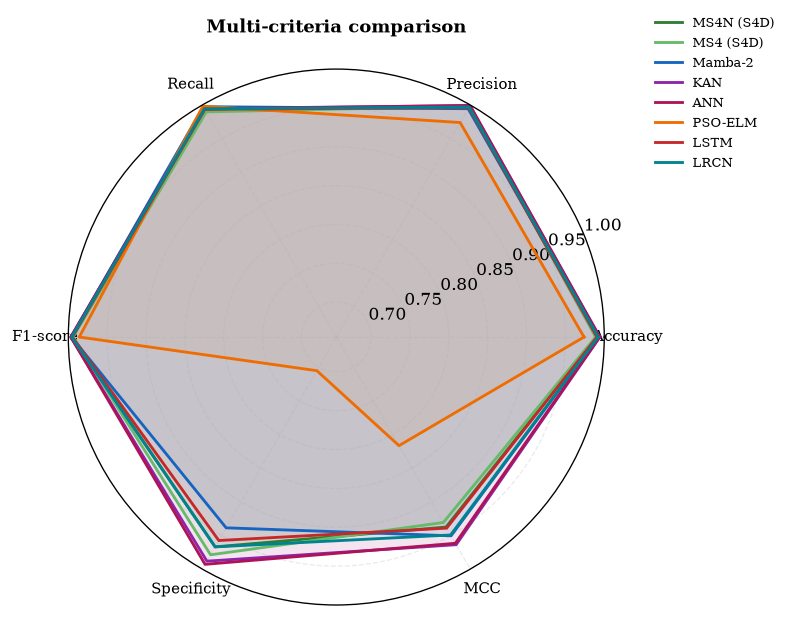

In [33]:
labels = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Specificity', 'MCC']
ang = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist(); ang += ang[:1]
fig, ax = plt.subplots(figsize=(5.8, 5.8), subplot_kw=dict(polar=True))
for name in ORDER:
    v = [df.loc[name, k] for k in labels]; v += v[:1]
    ax.plot(ang, v, lw=1.7, color=col(name), label=name)
    ax.fill(ang, v, color=col(name), alpha=0.06)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(max(df[labels].to_numpy().min() - 0.05, 0), 1.0)
ax.set_title('Multi-criteria comparison', pad=22)
ax.legend(loc='upper right', bbox_to_anchor=(1.34, 1.12), fontsize=8)
fig.savefig(f'{OUT_DIR}/fig7_radar.png'); plt.show()

### Figure 8 — PSO convergence

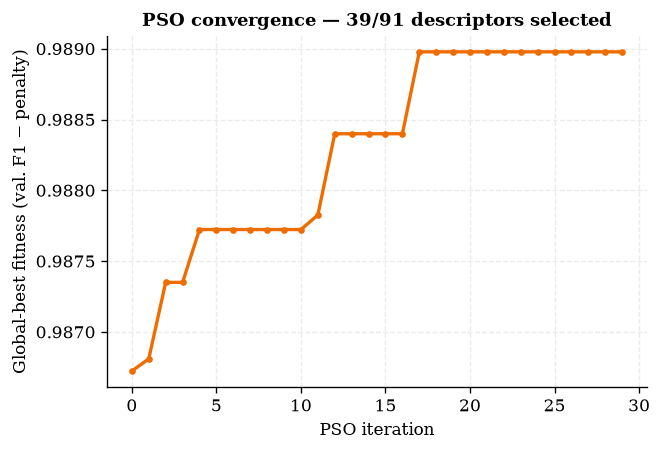

In [34]:
fig, ax = plt.subplots(figsize=(5.8, 3.8))
ax.plot(pso.history_, color=PALETTE['PSO-ELM'], lw=2, marker='o', ms=3)
ax.set_xlabel('PSO iteration')
ax.set_ylabel('Global-best fitness (val. F1 − penalty)')
ax.set_title(f'PSO convergence — {int(pso.mask_.sum())}/{N_DESC} descriptors selected')
fig.savefig(f'{OUT_DIR}/fig8_pso_convergence.png'); plt.show()

## 8. Noise-robustness sweep

The headline table is a single operating point. This sweep is the more
informative result: it shows *where* each architecture degrades, and it makes
the saturation on clean data explicit rather than hiding it.

Runtime is roughly (number of SNR levels) × the Section 5 cost. Trim
`SWEEP_SNRS` or `SWEEP_MODELS` if you need it faster.

In [35]:
RUN_SWEEP    = True          # set False to skip
SWEEP_SNRS   = [None, 20, 10, 5, 0, -5, -10]
SWEEP_MODELS = ['MS4N (S4D)', 'Mamba-2', 'KAN', 'ANN', 'PSO-ELM', 'LSTM', 'LRCN']
SWEEP_EPOCHS = 15

sweep = {}
if RUN_SWEEP:
    for snr in SWEEP_SNRS:
        p = build_pooled(snr_db=snr, verbose=False)
        Xtr, ytr, _ = p['train']; Xva, yva, _ = p['val']; Xte, yte, _ = p['test']
        Ftr, Fva, Fte = (handcrafted_features(a) for a in (Xtr, Xva, Xte))
        mu, sd = Ftr.mean(0), Ftr.std(0) + 1e-8
        Ftr_s, Fva_s, Fte_s = ((a - mu)/sd for a in (Ftr, Fva, Fte))
        row = {}
        for name in SWEEP_MODELS:
            if name == 'PSO-ELM':
                mdl = PSOELM(n_particles=15, n_iter=15).fit(Ftr_s, ytr, Fva_s, yva,
                                                            verbose=False)
                yp = mdl.predict(Fte_s)
            elif name == 'KAN':
                mdl, _, _ = train_torch(KANClassifier(Ftr.shape[1]), Ftr_s, ytr,
                                        Fva_s, yva, epochs=SWEEP_EPOCHS, verbose=False)
                yp, _ = predict_torch(mdl, Fte_s)
            elif name == 'ANN':
                mdl, _, _ = train_torch(ANNClassifier(Ftr.shape[1]), Ftr_s, ytr,
                                        Fva_s, yva, epochs=SWEEP_EPOCHS, verbose=False)
                yp, _ = predict_torch(mdl, Fte_s)
            else:
                mdl, _, _ = train_torch(SEQ_MODELS[name](), Xtr, ytr, Xva, yva,
                                        epochs=SWEEP_EPOCHS, verbose=False)
                yp, _ = predict_torch(mdl, Xte)
            row[name] = f1_score(yte, yp, average='macro', zero_division=0)
        sweep[snr] = row
        print(f'SNR {str(snr):>5} dB  ->  ' +
              '  '.join(f'{k} {v:.3f}' for k, v in row.items()), flush=True)

    sw = pd.DataFrame(sweep).T
    sw.index = ['clean' if i is None else f'{i:g}' for i in sw.index]
    sw.to_csv(f'{OUT_DIR}/results_snr_sweep.csv')
    display(sw.round(4))

SNR  None dB  ->  MS4N (S4D) 1.000  Mamba-2 1.000  KAN 1.000  ANN 1.000  PSO-ELM 0.997  LSTM 1.000  LRCN 0.991
SNR    20 dB  ->  MS4N (S4D) 0.999  Mamba-2 1.000  KAN 0.999  ANN 1.000  PSO-ELM 0.979  LSTM 0.997  LRCN 1.000
SNR    10 dB  ->  MS4N (S4D) 0.995  Mamba-2 0.992  KAN 0.997  ANN 0.996  PSO-ELM 0.950  LSTM 0.995  LRCN 0.996
SNR     5 dB  ->  MS4N (S4D) 0.971  Mamba-2 0.993  KAN 0.994  ANN 0.982  PSO-ELM 0.919  LSTM 0.975  LRCN 0.992
SNR     0 dB  ->  MS4N (S4D) 0.953  Mamba-2 0.975  KAN 0.981  ANN 0.965  PSO-ELM 0.883  LSTM 0.940  LRCN 0.971
SNR    -5 dB  ->  MS4N (S4D) 0.932  Mamba-2 0.943  KAN 0.969  ANN 0.950  PSO-ELM 0.909  LSTM 0.906  LRCN 0.948
SNR   -10 dB  ->  MS4N (S4D) 0.919  Mamba-2 0.927  KAN 0.966  ANN 0.945  PSO-ELM 0.883  LSTM 0.886  LRCN 0.920


,MS4N (S4D),Mamba-2,KAN,ANN,PSO-ELM,LSTM,LRCN
nan,1.0000,1.0000,1.0000,1.0000,0.9968,1.0000,0.9911
20,0.9994,1.0000,0.9994,1.0000,0.9794,0.9968,1.0000
10,0.9949,0.9918,0.9974,0.9962,0.9500,0.9949,0.9962
5,0.9710,0.9929,0.9942,0.9818,0.9188,0.9750,0.9923
0,0.9529,0.9746,0.9810,0.9647,0.8826,0.9399,0.9708
-5,0.9322,0.9431,0.9687,0.9497,0.9086,0.9062,0.9481
-10,0.9194,0.9270,0.9657,0.9445,0.8829,0.8864,0.9201


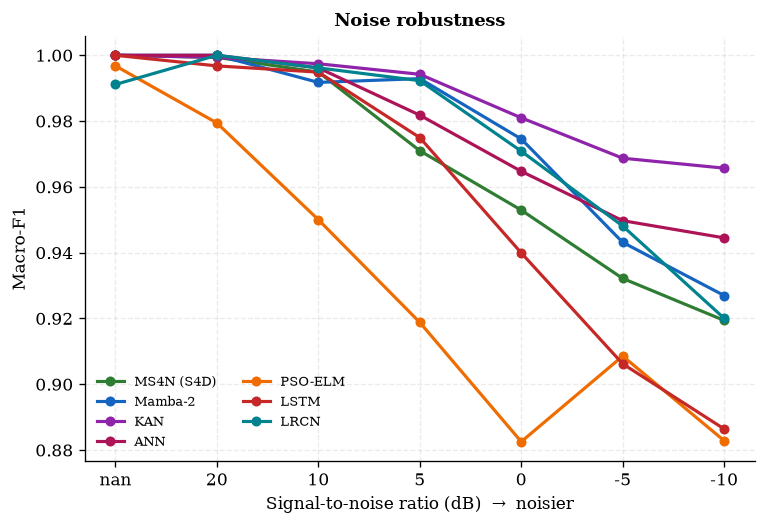

In [36]:
if RUN_SWEEP and sweep:
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    xs = np.arange(len(sw.index))
    for name in sw.columns:
        ax.plot(xs, sw[name], marker='o', ms=5, lw=1.9, color=col(name), label=name)
    ax.set_xticks(xs); ax.set_xticklabels(sw.index)
    ax.set_xlabel('Signal-to-noise ratio (dB)  →  noisier')
    ax.set_ylabel('Macro-F1'); ax.set_title('Noise robustness')
    ax.legend(fontsize=8, ncol=2)
    fig.savefig(f'{OUT_DIR}/fig9_snr_sweep.png'); plt.show()

## 9. Cross-configuration transfer

Trains on three line configurations and tests on the fourth, held out entirely.
This asks whether a relay trained on one set of topologies transfers to an
unseen one — a harder and more publishable claim than in-distribution accuracy,
and the setting where architectural inductive bias should actually matter.

held-out TL-1:  MS4N (S4D) 0.936  Mamba-2 0.967  KAN 0.939  ANN 0.909  LSTM 0.964  LRCN 0.987
held-out TL-2:  MS4N (S4D) 0.725  Mamba-2 0.772  KAN 0.742  ANN 0.827  LSTM 0.727  LRCN 0.853
held-out TL-3:  MS4N (S4D) 0.932  Mamba-2 0.953  KAN 0.910  ANN 0.878  LSTM 0.915  LRCN 0.913
held-out TL-4:  MS4N (S4D) 0.557  Mamba-2 0.523  KAN 0.482  ANN 0.446  LSTM 0.512  LRCN 0.625


,MS4N (S4D),Mamba-2,KAN,ANN,LSTM,LRCN
TL-1,0.9361,0.9667,0.9392,0.9093,0.9640,0.9870
TL-2,0.7251,0.7721,0.7415,0.8273,0.7273,0.8533
TL-3,0.9323,0.9527,0.9096,0.8776,0.9149,0.9129
TL-4,0.5575,0.5231,0.4824,0.4456,0.5118,0.6253


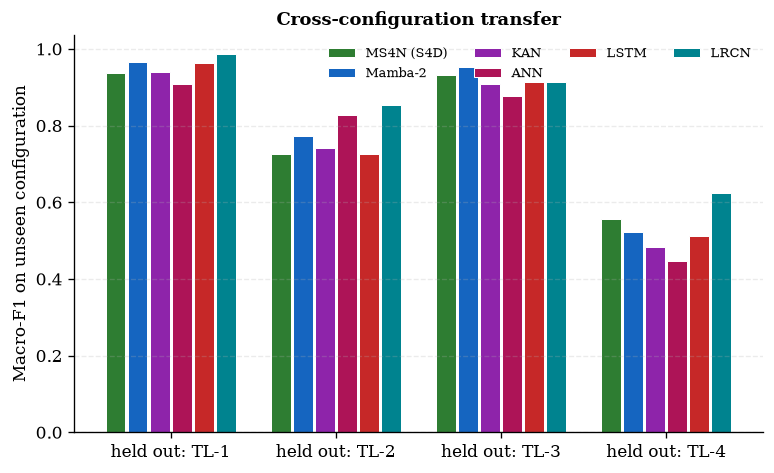

In [38]:
RUN_TRANSFER = True
TRANSFER_MODELS = ['MS4N (S4D)', 'Mamba-2', 'KAN', 'ANN', 'LSTM', 'LRCN']
transfer = {}

if RUN_TRANSFER:
    for held in CASES:
        src = [c for c in CASES if c != held]
        p_src = build_pooled(cases=src,     snr_db=SNR_DB, verbose=False)
        p_tgt = build_pooled(cases=[held],  snr_db=SNR_DB, verbose=False)
        Xtr = np.concatenate([p_src['train'][0], p_src['val'][0]])
        ytr = np.concatenate([p_src['train'][1], p_src['val'][1]])
        Xte = np.concatenate([p_tgt[k][0] for k in ('train', 'val', 'test')])
        yte = np.concatenate([p_tgt[k][1] for k in ('train', 'val', 'test')])
        Ftr_t = handcrafted_features(Xtr); Fte_t = handcrafted_features(Xte)
        Fva_t = handcrafted_features(p_src['val'][0])
        mu_t, sd_t = Ftr_t.mean(0), Ftr_t.std(0) + 1e-8
        Ftr_ts, Fva_ts, Fte_ts = ((a - mu_t)/sd_t for a in (Ftr_t, Fva_t, Fte_t))
        row = {}
        for name in TRANSFER_MODELS:
            if name == 'ANN':
                mdl, _, _ = train_torch(ANNClassifier(Ftr_ts.shape[1]), Ftr_ts, ytr,
                                        Fva_ts, p_src['val'][1], epochs=15, verbose=False)
                yp, _ = predict_torch(mdl, Fte_ts)
            elif name == 'KAN':
                mdl, _, _ = train_torch(KANClassifier(Ftr_ts.shape[1]), Ftr_ts, ytr,
                                        Fva_ts, p_src['val'][1], epochs=15, verbose=False)
                yp, _ = predict_torch(mdl, Fte_ts)
            else:
                mdl, _, _ = train_torch(SEQ_MODELS[name](), Xtr, ytr,
                                        p_src['val'][0], p_src['val'][1],
                                        epochs=15, verbose=False)
                yp, _ = predict_torch(mdl, Xte)
            row[name] = f1_score(yte, yp, average='macro', zero_division=0)
        transfer[held] = row
        print(f'held-out {held}:  ' + '  '.join(f'{k} {v:.3f}' for k, v in row.items()),
              flush=True)

    tf = pd.DataFrame(transfer).T
    tf.to_csv(f'{OUT_DIR}/results_transfer.csv')
    display(tf.round(4))

    fig, ax = plt.subplots(figsize=(7.4, 4.3))
    xs = np.arange(len(tf.index)); w = 0.8/len(tf.columns)
    for i, name in enumerate(tf.columns):
        ax.bar(xs - 0.4 + w*(i+0.5), tf[name], w*0.9, label=name, color=col(name),
               edgecolor='white', lw=0.6)
    ax.set_xticks(xs); ax.set_xticklabels([f'held out: {c}' for c in tf.index])
    ax.set_ylabel('Macro-F1 on unseen configuration')
    ax.set_title('Cross-configuration transfer'); ax.legend(fontsize=8, ncol=4)
    ax.grid(axis='x', visible=False)
    fig.savefig(f'{OUT_DIR}/fig10_transfer.png'); plt.show()

## 10. Notes for the write-up

**Method section.** State the window length and stride, the tiling collapse, the
position-based split with guard band, and the SNR. Reviewers who re-run a naive
pipeline will get ~100% and wonder why your numbers are lower — the answer is
that theirs leak.

**Dataset section.** The TL-3/TL-4 duplication needs a sentence. If a reviewer
diffs those two files, four configurations become three. Say which file you used
for TL-3 and why.

**Results section.** Report macro-F1 alongside accuracy: the test set is ~92%
fault, so a trivial always-fault classifier already scores ~0.92 accuracy. Quote
that baseline so the gains are interpretable. For a protection application,
missed-detection rate and false-alarm rate carry more weight than accuracy.

**Claims to avoid.**
- Do not claim per-configuration generalisation from TL-3 vs TL-4 results.
- Do not claim a clean-data ranking — at ≈1.000 the differences are noise. The
  SNR sweep and the transfer experiment are where any real ranking lives.
- Do not compare parameter counts against the source paper's MONSTER/UEA
  numbers; different task, different input dimensionality.

**Reproducibility.** Every model shares one training protocol and one seed.
For camera-ready, run 5 seeds and report mean ± std — reviewers ask, and single
seeds on a saturated task are not persuasive.